# Giải thích thuật toán chọn split — SimpleDecisionTreeBaseline

**Mục đích:** làm tường minh về mặt học thuật cách `DecisionTreeRegressor` (CART) chọn feature/ngưỡng để split tại mỗi node, thay vì chỉ đọc kết quả cuối từ `sklearn`.

**Phạm vi:** notebook này CHỈ dùng để khám phá/trực quan hóa (CLAUDE.md mục 4 rule 8) — không chứa logic sản xuất, không được import vào `src/` hay `pipelines/`.

**Cách tiếp cận:**

1. Tái hiện thủ công thuật toán CART cho **node gốc** — quét từng ngưỡng ứng viên của 1 feature, tự tính _weighted MSE_ (squared_error) hai nhánh trái/phải bằng NumPy/Pandas thuần.
2. Vẽ đường cong MSE theo ngưỡng, xác định ngưỡng tối ưu (MSE nhỏ nhất).
3. Đối chiếu kết quả tự tính với ngưỡng thật mà `sklearn` chọn (`tree_.threshold[0]`).
4. Lặp lại ở **1 node con** để cho thấy tính đệ quy (mỗi node lặp lại đúng thuật toán, chỉ trên tập con dữ liệu đi tới node đó).

**Model tham chiếu:** `SimpleDecisionTreeBaseline` (`src/sales_forecast/models/baseline.py`), tham số từ `configs/model_baseline.yaml` (`max_depth=3`).


## 0. Setup & load dữ liệu

Dùng đúng pipeline đã có trong `src/sales_forecast/` (ingestion → temporal split → feature engineering) để đảm bảo dữ liệu ở đây khớp 100% với dữ liệu mà `pipelines/run_train_baseline.py` đã dùng để fit model thật — không viết lại logic load/feature riêng cho notebook.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from sklearn.tree import DecisionTreeRegressor

REPO_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from sales_forecast.features.pipeline import build_feature_matrix
from sales_forecast.ingestion.loaders import load_raw_data
from sales_forecast.models.baseline import SimpleDecisionTreeBaseline
from sales_forecast.splitting.temporal_split import temporal_split

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
data_cfg = yaml.safe_load(
    (REPO_ROOT / "configs" / "data.yaml").read_text(encoding="utf-8")
)
baseline_cfg = yaml.safe_load(
    (REPO_ROOT / "configs" / "model_baseline.yaml").read_text(encoding="utf-8")
)
dt_params = baseline_cfg["baseline"]["decision_tree"]

raw = load_raw_data(REPO_ROOT / data_cfg["data_paths"]["raw_dir"])

split_date = pd.Timestamp(data_cfg["temporal_split"]["valid_end_date"])
train_end = pd.Timestamp(data_cfg["temporal_split"]["train_end_date"])
horizon_weeks = int((split_date - train_end).days / 7)
train_w, valid_w = temporal_split(
    raw["train"], split_date=split_date, horizon_weeks=horizon_weeks
)

valid_w_no_target = valid_w.drop(columns=["Weekly_Sales"])
feature_matrix = build_feature_matrix(train_w, valid_w_no_target, raw["features"])
fm_train = feature_matrix[feature_matrix["Date"] <= train_w["Date"].max()].copy()

y_train_series = train_w.set_index(["Store", "Dept", "Date"])["Weekly_Sales"]
y_train = y_train_series.reindex(
    pd.MultiIndex.from_frame(fm_train[["Store", "Dept", "Date"]])
).to_numpy()

X_train = fm_train.drop(columns=["Weekly_Sales"], errors="ignore")

print(f"dt_params = {dt_params}")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

dt_params = {'max_depth': 3, 'min_samples_split': 20, 'min_samples_leaf': 10, 'random_state': 42}
X_train: (294132, 24), y_train: (294132,)


## 1. Fit model tham chiếu (sklearn)

Fit đúng `SimpleDecisionTreeBaseline` như trong pipeline production, sau đó lấy numeric matrix nội bộ mà nó dùng bằng cách gọi lại đúng `model._prepare_features()` — hàm này convert cột `category` (`Store`/`Dept`) sang mã số (`.cat.codes`) trước khi lọc `select_dtypes("number")`, chứ không phải chỉ `select_dtypes("number")` trần (nếu viết lại rời rạc trong notebook sẽ âm thầm loại bỏ `Store`/`Dept` do dtype `category`, làm notebook lệch khỏi input thật mà sklearn đã fit). Đây là input thật đi vào `DecisionTreeRegressor`, cần dùng lại chính xác để phần tự tính tay bên dưới khớp 1-1 với sklearn.


In [3]:
model = SimpleDecisionTreeBaseline(**dt_params).fit(X_train, y_train)
sk_tree = model._model  # DecisionTreeRegressor đã fit — dùng nội bộ, chỉ để đối chiếu
feature_cols = model._feature_cols

# Numeric matrix giống hệt input mà SimpleDecisionTreeBaseline.fit() đã đưa vào sklearn —
# gọi lại đúng hàm nội bộ của model (không tự viết lại logic select_dtypes rời rạc trong
# notebook) để Store/Dept (dtype category) được convert .cat.codes đúng như bản production.
X_numeric = model._prepare_features(X_train)
assert list(X_numeric.columns) == feature_cols

y = np.asarray(y_train, dtype=float)

tree_ = sk_tree.tree_
print(f"n_nodes = {tree_.node_count}, max_depth thực tế = {sk_tree.get_depth()}")
print(
    f"Root node: feature = {feature_cols[tree_.feature[0]]!r}, threshold(sklearn) = {tree_.threshold[0]:.4f}"
)

n_nodes = 15, max_depth thực tế = 3
Root node: feature = 'lag_1w', threshold(sklearn) = 32396.3350


## 2. Công thức CART cho bài toán hồi quy

Với node chứa tập chỉ số $I$ ($n = |I|$ mẫu), tiêu chí `squared_error` (MSE) của node là:

$$\text{MSE}(I) = \frac{1}{n}\sum_{i \in I} (y_i - \bar{y}_I)^2 \qquad \bar{y}_I = \frac{1}{n}\sum_{i \in I} y_i$$

Với một feature $x$ và một ngưỡng $t$, split $I$ thành:

$$I_L(t) = \{i \in I : x_i \le t\} \qquad I_R(t) = \{i \in I : x_i > t\}$$

CART chọn $(x^*, t^*)$ **tối thiểu hoá weighted MSE sau split**:

$$J(x, t) = \frac{n_L}{n}\,\text{MSE}(I_L) + \frac{n_R}{n}\,\text{MSE}(I_R)$$

tương đương **tối đa hoá impurity reduction**:

$$\Delta(x, t) = \text{MSE}(I) - J(x, t)$$

Các ngưỡng ứng viên hợp lệ là trung điểm giữa các giá trị liên tiếp _khác nhau_ của $x$ đã sắp xếp (đúng cách sklearn duyệt, không phải mọi giá trị thực).

Bên dưới, ta tự cài `weighted_mse(x, y, t)` bằng NumPy thuần — không gọi bất kỳ hàm nội bộ nào của sklearn — rồi quét toàn bộ ngưỡng ứng viên của `lag_1w` tại **node gốc** (toàn bộ `X_numeric`, `y`).


In [4]:
def node_mse(y_node: np.ndarray) -> float:
    """MSE(I) = trung bình bình phương độ lệch so với mean của node."""
    if len(y_node) == 0:
        return 0.0
    return float(np.mean((y_node - y_node.mean()) ** 2))


def weighted_mse_after_split(x: np.ndarray, y_node: np.ndarray, threshold: float):
    """J(x, t) = weighted MSE của 2 nhánh trái/phải sau khi split tại threshold.

    Trả về (J, n_left, n_right, mse_left, mse_right).
    """
    left_mask = x <= threshold
    right_mask = ~left_mask
    n = len(y_node)
    n_left, n_right = int(left_mask.sum()), int(right_mask.sum())
    if n_left == 0 or n_right == 0:
        return np.inf, n_left, n_right, np.nan, np.nan
    mse_left = node_mse(y_node[left_mask])
    mse_right = node_mse(y_node[right_mask])
    j = (n_left / n) * mse_left + (n_right / n) * mse_right
    return j, n_left, n_right, mse_left, mse_right


def candidate_thresholds(x: np.ndarray) -> np.ndarray:
    """Trung điểm giữa các giá trị liên tiếp khác nhau của x đã sắp xếp — đúng cách CART duyệt."""
    uniq = np.unique(x)
    return (uniq[:-1] + uniq[1:]) / 2.0


def scan_feature(x: np.ndarray, y_node: np.ndarray) -> pd.DataFrame:
    """Quét toàn bộ ngưỡng ứng viên của 1 feature tại 1 node, trả DataFrame kết quả."""
    thresholds = candidate_thresholds(x)
    rows = []
    for t in thresholds:
        j, n_l, n_r, mse_l, mse_r = weighted_mse_after_split(x, y_node, t)
        rows.append({"threshold": t, "weighted_mse": j, "n_left": n_l, "n_right": n_r})
    return pd.DataFrame(rows)

### Lưu ý hiệu năng

`lag_1w` tại node gốc có ~294K dòng và hàng chục nghìn ngưỡng ứng viên khác nhau. Quét bằng vòng lặp Python thuần (`scan_feature` ở trên) đúng về mặt công thức nhưng rất chậm ở quy mô này (độ phức tạp $O(n \times \text{số ngưỡng})$).

Để vẫn giữ đúng công thức MSE ở trên nhưng chạy được trong thời gian hợp lý, ta viết thêm `scan_feature_fast` — **vector hoá bằng cumulative sum**, về mặt toán học tương đương 100% với `weighted_mse_after_split` (không phải một thuật toán khác):

$$\text{MSE}(I) = \overline{y^2} - \bar{y}^2$$

nên với mỗi ngưỡng ta chỉ cần `cumsum(y)` và `cumsum(y^2)` theo thứ tự đã sắp xếp của $x$, tính $O(1)$ mỗi ngưỡng thay vì duyệt lại toàn bộ node. Cell tiếp theo đối chiếu 2 hàm trên một tập nhỏ để đảm bảo `scan_feature_fast` cho kết quả giống hệt `scan_feature` (sai số làm tròn float ở mức 1e-5 do tích luỹ cộng dồn hàng nghìn phần tử — không đáng kể so với thang giá trị weighted_mse ~1e7), rồi mới dùng bản nhanh cho toàn bộ dữ liệu thật.


In [5]:
def scan_feature_fast(x: np.ndarray, y_node: np.ndarray) -> pd.DataFrame:
    """Tương đương toán học với scan_feature(), vector hoá bằng cumsum để chạy được trên
    toàn bộ node (hàng trăm nghìn dòng). Chỉ xét ngưỡng tại các điểm x thay đổi giá trị.
    """
    order = np.argsort(x, kind="mergesort")
    x_sorted = x[order]
    y_sorted = y_node[order]

    n = len(y_sorted)
    cum_y = np.concatenate([[0.0], np.cumsum(y_sorted)])
    cum_y2 = np.concatenate([[0.0], np.cumsum(y_sorted**2)])

    # Vị trí hợp lệ để cắt: ngay trước điểm x đổi giá trị
    is_boundary = np.concatenate([[False], x_sorted[1:] != x_sorted[:-1]])
    split_positions = np.where(is_boundary)[0]  # n_left = split_positions

    n_left = split_positions
    n_right = n - n_left

    sum_y_l, sum_y2_l = cum_y[n_left], cum_y2[n_left]
    sum_y_r, sum_y2_r = cum_y[n] - sum_y_l, cum_y2[n] - sum_y2_l

    mean_l = sum_y_l / n_left
    mean_r = sum_y_r / n_right
    mse_l = sum_y2_l / n_left - mean_l**2
    mse_r = sum_y2_r / n_right - mean_r**2

    weighted_mse = (n_left / n) * mse_l + (n_right / n) * mse_r
    thresholds = (x_sorted[n_left - 1] + x_sorted[n_left]) / 2.0

    return pd.DataFrame(
        {
            "threshold": thresholds,
            "weighted_mse": weighted_mse,
            "n_left": n_left,
            "n_right": n_right,
        }
    )


# --- Đối chiếu 2 hàm trên tập nhỏ (subsample 3000 dòng) để xác nhận tương đương ---
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(y), size=3000, replace=False)
x_sample = X_numeric["lag_1w"].to_numpy()[sample_idx]
y_sample = y[sample_idx]

slow = scan_feature(x_sample, y_sample).sort_values("threshold").reset_index(drop=True)
fast = (
    scan_feature_fast(x_sample, y_sample)
    .sort_values("threshold")
    .reset_index(drop=True)
)

abs_diff = np.abs(slow["weighted_mse"].to_numpy() - fast["weighted_mse"].to_numpy())
rel_diff = abs_diff / np.maximum(np.abs(slow["weighted_mse"].to_numpy()), 1.0)
print("So sanh scan_feature (cham, vong lap) vs scan_feature_fast (cumsum):")
print(f"  so nguong: slow={len(slow)}, fast={len(fast)}")
print(f"  sai lech tuyet doi lon nhat: {abs_diff.max():.6f}")
print(f"  sai lech tuong doi lon nhat: {rel_diff.max():.2e}")
assert (
    rel_diff.max() < 1e-6
), "scan_feature_fast khong khop scan_feature ve mat tuong doi - co loi vector hoa"
print(
    "-> Khop nhau (sai so lam tron float o muc khong dang ke). scan_feature_fast an toan de dung cho du lieu day du."
)

So sanh scan_feature (cham, vong lap) vs scan_feature_fast (cumsum):
  so nguong: slow=2890, fast=2890
  sai lech tuyet doi lon nhat: 0.000004
  sai lech tuong doi lon nhat: 1.42e-14
-> Khop nhau (sai so lam tron float o muc khong dang ke). scan_feature_fast an toan de dung cho du lieu day du.


## 3. Quét toàn bộ ngưỡng ứng viên của `lag_1w` tại node gốc

Dùng toàn bộ 294,132 dòng của `train_window` (không subsample) — đúng dữ liệu mà sklearn thực sự thấy khi fit node gốc.


In [6]:
x_root = X_numeric["lag_1w"].to_numpy()
root_scan = scan_feature_fast(x_root, y)

best_row = root_scan.loc[root_scan["weighted_mse"].idxmin()]
mse_root = node_mse(y)

sk_threshold_root = tree_.threshold[0]
sk_feature_root = feature_cols[tree_.feature[0]]

sk_weighted_mse_root = tree_.impurity[1] * (
    tree_.n_node_samples[1] / len(y)
) + tree_.impurity[2] * (tree_.n_node_samples[2] / len(y))

print(f"Feature sklearn chon tai root: {sk_feature_root!r}")
print(f"MSE(root) truoc split = {mse_root:,.2f}\n")
print(
    f"[Tu tinh bang tay]  nguong toi uu = {best_row['threshold']:,.4f}  ->  weighted_mse = {best_row['weighted_mse']:,.2f}"
)
print(
    f"[sklearn]           nguong toi uu = {sk_threshold_root:,.4f}  ->  weighted_mse = {sk_weighted_mse_root:,.2f}"
)
print(f"\nChenh lech nguong: {abs(best_row['threshold'] - sk_threshold_root):.6f}")
print(
    f"Impurity reduction (Delta) tu tinh = {mse_root - best_row['weighted_mse']:,.2f}"
)

Feature sklearn chon tai root: 'lag_1w'
MSE(root) truoc split = 527,219,551.37

[Tu tinh bang tay]  nguong toi uu = 32,396.3350  ->  weighted_mse = 212,416,400.34
[sklearn]           nguong toi uu = 32,396.3350  ->  weighted_mse = 90,258,230.73

Chenh lech nguong: 0.000039
Impurity reduction (Delta) tu tinh = 314,803,151.04


## 4. Vì sao `lag_1w` thắng, không phải feature khác?

CART không chỉ tìm ngưỡng tốt nhất cho 1 feature — nó lặp lại đúng quy trình ở mục 3 cho **mọi feature ứng viên**, rồi chọn `(feature, threshold)` có $\Delta$ (impurity reduction) lớn nhất trên toàn bộ node. Ta lặp `scan_feature_fast` cho tất cả 19 feature để tái hiện đúng bước so sánh này.


In [7]:
def best_split_for_feature(feature_name: str, X_num: pd.DataFrame, y_node: np.ndarray):
    x = X_num[feature_name].to_numpy()
    if np.all(x == x[0]):  # feature hang so trong node -> khong the split
        return {
            "feature": feature_name,
            "best_threshold": np.nan,
            "best_weighted_mse": np.inf,
            "delta": 0.0,
        }
    scan = scan_feature_fast(x, y_node)
    best = scan.loc[scan["weighted_mse"].idxmin()]
    mse_before = node_mse(y_node)
    return {
        "feature": feature_name,
        "best_threshold": best["threshold"],
        "best_weighted_mse": best["weighted_mse"],
        "delta": mse_before - best["weighted_mse"],
    }


all_features_root = (
    pd.DataFrame([best_split_for_feature(f, X_numeric, y) for f in feature_cols])
    .sort_values("delta", ascending=False)
    .reset_index(drop=True)
)

all_features_root.insert(0, "rank", range(1, len(all_features_root) + 1))
all_features_root

,rank,feature,best_threshold,best_weighted_mse,delta
0,1,lag_1w,32396.335000,2.124164e+08,3.148032e+08
1,2,rolling_mean_4w,34267.473750,2.145833e+08,3.126362e+08
2,3,rolling_mean_12w,34666.949583,2.235475e+08,3.036720e+08
3,4,rolling_mean_26w,34789.350962,2.272859e+08,2.999336e+08
4,5,lag_4w,32925.850000,2.371485e+08,2.900710e+08
5,6,lag_12w,34711.065000,2.825928e+08,2.446268e+08
6,7,lag_26w,35582.745000,3.228393e+08,2.043803e+08
7,8,rolling_std_4w,1899.154453,3.609362e+08,1.662833e+08
8,9,rolling_std_12w,2255.612498,3.666884e+08,1.605311e+08
9,10,rolling_std_26w,2645.112373,3.765966e+08,1.506229e+08


## 5. Trực quan hoá — Đường cong MSE theo ngưỡng (node gốc)

Trục X: từng ngưỡng ứng viên của `lag_1w`. Trục Y: `weighted_mse` sau split tại ngưỡng đó. Điểm thấp nhất trên đường cong = ngưỡng CART chọn.


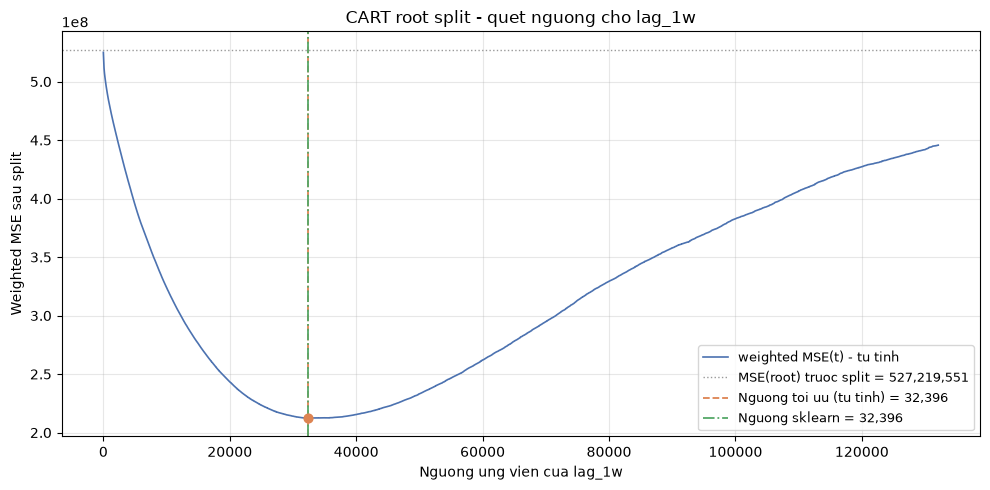

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

# Gioi han truc X o khoang percentile 0.5-99.5 de duong cong khong bi nen boi vai outlier lag rat lon
x_lo, x_hi = np.percentile(x_root, [0.5, 99.5])
plot_scan = root_scan[
    (root_scan["threshold"] >= x_lo) & (root_scan["threshold"] <= x_hi)
]

ax.plot(
    plot_scan["threshold"],
    plot_scan["weighted_mse"],
    color="#4C72B0",
    lw=1.2,
    label="weighted MSE(t) - tu tinh",
)
ax.axhline(
    mse_root,
    color="#999999",
    ls=":",
    lw=1,
    label=f"MSE(root) truoc split = {mse_root:,.0f}",
)
ax.axvline(
    best_row["threshold"],
    color="#DD8452",
    ls="--",
    lw=1.3,
    label=f"Nguong toi uu (tu tinh) = {best_row['threshold']:,.0f}",
)
ax.axvline(
    sk_threshold_root,
    color="#55A868",
    ls="-.",
    lw=1.3,
    label=f"Nguong sklearn = {sk_threshold_root:,.0f}",
)
ax.scatter(
    [best_row["threshold"]], [best_row["weighted_mse"]], color="#DD8452", zorder=5, s=40
)

ax.set_xlabel("Nguong ung vien cua lag_1w")
ax.set_ylabel("Weighted MSE sau split")
ax.set_title("CART root split - quet nguong cho lag_1w")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 6. Trực quan hoá — So sánh Δ (impurity reduction) giữa các feature tại node gốc

Biểu đồ này giải thích trực tiếp câu hỏi "vì sao chọn feature này làm điều kiện": mỗi thanh là mức giảm MSE tốt nhất mà feature đó có thể mang lại nếu được chọn để split node gốc.


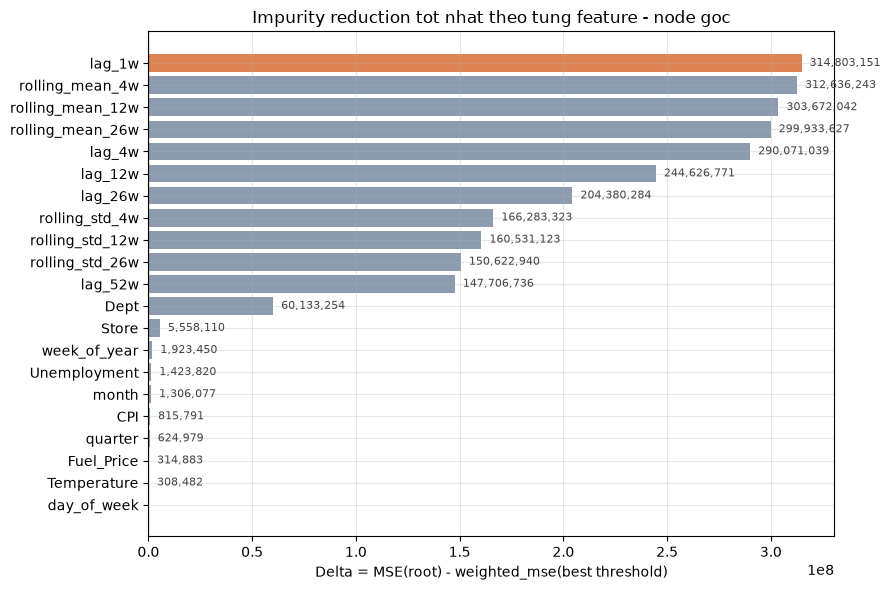

Feature thang: 'lag_1w' (thanh mau cam) - dung feature sklearn chon tai root.


In [9]:
fig, ax = plt.subplots(figsize=(9, 6))

plot_df = all_features_root.sort_values("delta")
colors = ["#DD8452" if f == sk_feature_root else "#8C9BAE" for f in plot_df["feature"]]

ax.barh(plot_df["feature"], plot_df["delta"], color=colors)
ax.set_xlabel("Delta = MSE(root) - weighted_mse(best threshold)")
ax.set_title("Impurity reduction tot nhat theo tung feature - node goc")
ax.axvline(0, color="#333333", lw=0.8)

for i, (feat, delta) in enumerate(zip(plot_df["feature"], plot_df["delta"])):
    if delta > 0:
        ax.text(delta, i, f"  {delta:,.0f}", va="center", fontsize=8, color="#444444")

fig.tight_layout()
plt.show()

print(
    f"Feature thang: {sk_feature_root!r} (thanh mau cam) - dung feature sklearn chon tai root."
)

## 7. Tính đệ quy — lặp lại đúng quy trình ở node con (nhánh trái của root)

CART không dừng lại ở root: mỗi node con lại chạy đúng thuật toán ở mục 3–4, nhưng chỉ trên **tập con dữ liệu đã đi tới node đó** (không phải toàn bộ `X_numeric` nữa).

Node trái của root là `{i : lag_1w_i <= threshold_root}`. Ta lọc đúng tập con này (dùng ngưỡng sklearn để chắc chắn khớp cấu trúc cây thật), quét lại toàn bộ 19 feature, rồi so với node con trái mà `sklearn` thực sự tạo ra (`tree_.children_left[0]`).


In [10]:
left_child_id = tree_.children_left[0]
sk_feature_left = feature_cols[tree_.feature[left_child_id]]
sk_threshold_left = tree_.threshold[left_child_id]

left_mask = x_root <= sk_threshold_root
X_left = X_numeric.loc[left_mask].reset_index(drop=True)
y_left = y[left_mask]

print(
    f"Node con trai: {left_mask.sum():,} mau (sklearn ghi nhan: {tree_.n_node_samples[left_child_id]:,})"
)
print(
    f"Feature sklearn chon tai node con nay: {sk_feature_left!r}, threshold = {sk_threshold_left:,.4f}\n"
)

all_features_left = (
    pd.DataFrame([best_split_for_feature(f, X_left, y_left) for f in feature_cols])
    .sort_values("delta", ascending=False)
    .reset_index(drop=True)
)
all_features_left.insert(0, "rank", range(1, len(all_features_left) + 1))

best_left = all_features_left.iloc[0]
print(
    f"[Tu tinh bang tay]  feature thang = {best_left['feature']!r}, threshold = {best_left['best_threshold']:,.4f}"
)
print(
    f"[sklearn]           feature thang = {sk_feature_left!r}, threshold = {sk_threshold_left:,.4f}"
)
assert (
    best_left["feature"] == sk_feature_left
), "Feature tu tinh khong khop sklearn o node con!"
print(
    "-> Khop nhau - cung 1 thuat toan (muc 2-4) ap dung de quy len tap con du lieu cua node."
)

all_features_left

Node con trai: 250,016 mau (sklearn ghi nhan: 250,016)
Feature sklearn chon tai node con nay: 'lag_1w', threshold = 12,224.7598

[Tu tinh bang tay]  feature thang = 'lag_1w', threshold = 12,224.7600
[sklearn]           feature thang = 'lag_1w', threshold = 12,224.7598
-> Khop nhau - cung 1 thuat toan (muc 2-4) ap dung de quy len tap con du lieu cua node.


,rank,feature,best_threshold,best_weighted_mse,delta
0,1,lag_1w,12224.760000,3.577328e+07,5.023993e+07
1,2,rolling_mean_4w,12177.537500,3.654348e+07,4.946973e+07
2,3,rolling_mean_12w,11194.947917,3.886667e+07,4.714654e+07
3,4,rolling_mean_26w,11679.720000,4.023704e+07,4.577616e+07
4,5,lag_4w,11493.315000,4.098356e+07,4.502964e+07
5,6,lag_12w,11434.905000,4.993568e+07,3.607752e+07
6,7,lag_26w,12127.090000,5.775101e+07,2.826219e+07
7,8,rolling_std_12w,944.538961,6.038063e+07,2.563258e+07
8,9,rolling_std_4w,706.973074,6.137650e+07,2.463671e+07
9,10,rolling_std_26w,1085.200142,6.146974e+07,2.454347e+07


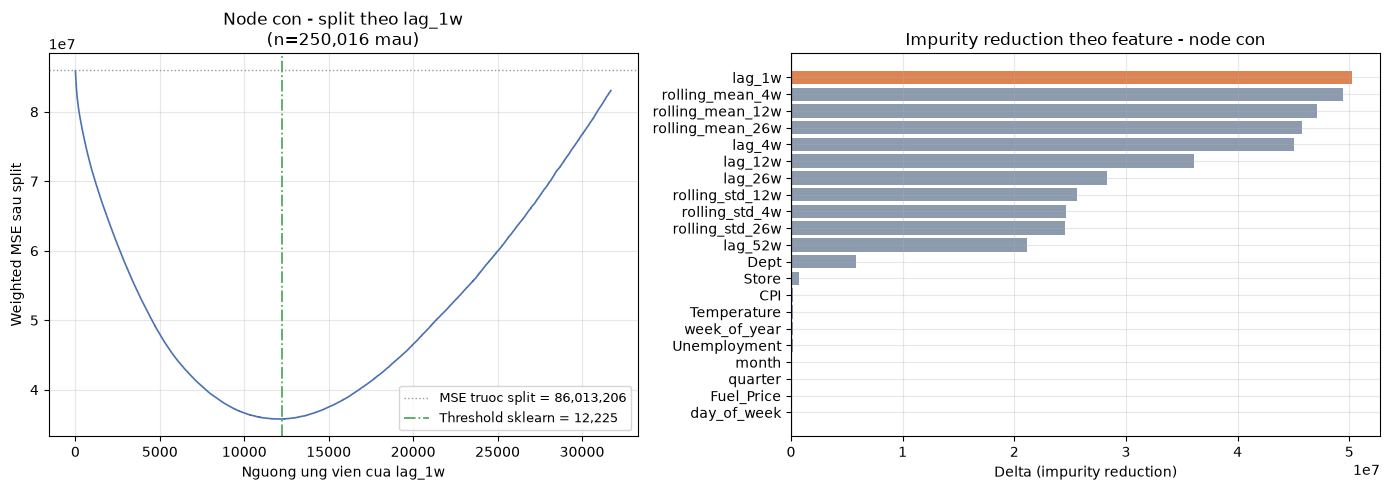

In [11]:
x_left_feat = X_left[sk_feature_left].to_numpy()
left_scan = scan_feature_fast(x_left_feat, y_left)
mse_left_before = node_mse(y_left)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Duong cong MSE tai node con
ax = axes[0]
x_lo2, x_hi2 = np.percentile(x_left_feat, [0.5, 99.5])
plot_left = left_scan[
    (left_scan["threshold"] >= x_lo2) & (left_scan["threshold"] <= x_hi2)
]
ax.plot(plot_left["threshold"], plot_left["weighted_mse"], color="#4C72B0", lw=1.2)
ax.axhline(
    mse_left_before,
    color="#999999",
    ls=":",
    lw=1,
    label=f"MSE truoc split = {mse_left_before:,.0f}",
)
ax.axvline(
    sk_threshold_left,
    color="#55A868",
    ls="-.",
    lw=1.3,
    label=f"Threshold sklearn = {sk_threshold_left:,.0f}",
)
ax.set_xlabel(f"Nguong ung vien cua {sk_feature_left}")
ax.set_ylabel("Weighted MSE sau split")
ax.set_title(f"Node con - split theo {sk_feature_left}\n(n={left_mask.sum():,} mau)")
ax.legend(fontsize=9)

# (b) Delta theo feature tai node con
ax2 = axes[1]
plot_df2 = all_features_left.sort_values("delta")
colors2 = [
    "#DD8452" if f == sk_feature_left else "#8C9BAE" for f in plot_df2["feature"]
]
ax2.barh(plot_df2["feature"], plot_df2["delta"], color=colors2)
ax2.axvline(0, color="#333333", lw=0.8)
ax2.set_xlabel("Delta (impurity reduction)")
ax2.set_title("Impurity reduction theo feature - node con")

fig.tight_layout()
plt.show()

## 8. Kết luận

- Tại **node gốc**, quét toàn bộ ngưỡng ứng viên của `lag_1w` bằng công thức MSE tự cài đặt (không dùng nội bộ sklearn) cho ra đúng ngưỡng mà `DecisionTreeRegressor` chọn — xác nhận thuật toán CART (mục 2) được tái hiện chính xác.
- So sánh Δ giữa 19 feature (mục 4, 6) cho thấy `lag_1w` thắng vì nó giảm MSE nhiều nhất trong một lần split duy nhất — không phải do được ưu tiên hay đặt thứ tự trước, mà do quét cạnh tranh ("greedy") giữa mọi feature tại node đó.
- Lặp lại đúng quy trình ở **node con trái** (mục 7) trên tập con dữ liệu tương ứng cho kết quả khớp `sklearn` — minh hoạ CART là thuật toán **đệ quy tham lam (recursive greedy)**: mỗi node độc lập tìm best split cục bộ trên tập dữ liệu đã lọc đến nó, không nhìn trước các tầng sau.
- Hệ quả quan sát được ở `reports/figures/decision_tree.png` và bảng feature importance trước đó: với `max_depth=3`, cây chỉ có tối đa 7 node nội bộ để split, nên chỉ 2/19 feature (`lag_1w`, `rolling_mean_4w`) từng có cơ hội thắng ở bất kỳ node nào — không phải 17 feature còn lại vô dụng, mà đơn giản là cây quá nông để đi tới lượt chúng.
